# AMS 597 – Research Question 3: Accident Severity Prediction
**Authors:** Shane Patandin, Matthew Tranquada, Vraj Patel, Kaushal Patel, Sur Vaghasiya

## Research Question
Can machine learning models trained on environmental and infrastructure features at the time of a Long Island accident predict whether that accident will be high-severity (Severity 3–4)?

We compare two models:
- **Logistic Regression** — interpretable baseline
- **XGBoost** — gradient-boosted trees; state-of-the-art for tabular data

Primary evaluation metric: **ROC-AUC** (preferred over accuracy given 5.86:1 class imbalance) **F1-Score** for comparison.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    ConfusionMatrixDisplay, f1_score
)
import xgboost as xgb

SEED = 597
np.random.seed(SEED)

print(f'XGBoost version : {xgb.__version__}')

XGBoost version : 3.2.0


## 2. Load Data

In [2]:
df = pd.read_csv('./data/li_accidents_clean.csv')

print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nSeverity distribution:')
print(df['Severity'].value_counts().sort_index())

Loaded: 33,228 rows x 48 columns

Severity distribution:
Severity
1      160
2    28222
3     3930
4      916
Name: count, dtype: int64


## 3. Feature Engineering

In [3]:
# ── Binary outcome ───────────────────────────────────────────────────────────
# While we could have used multi-class classification, we opted to bin them into binary variables since the model struggles with differentiating Severity 2 and 3.
# 0 = low severity (1-2)  |  1 = high severity (3-4)
df['severity_binary'] = df['Severity'].isin([3, 4]).astype(int)

neg = (df['severity_binary'] == 0).sum()
pos = (df['severity_binary'] == 1).sum()
imbalance_ratio = neg / pos
# Note that we have a high imbalance ratio, which is why we use the ROC-AUC as our evaluation metric. 

print('Class distribution:')
print(df['severity_binary'].value_counts())
print(f'Imbalance ratio: {imbalance_ratio:.2f}:1')

Class distribution:
severity_binary
0    28382
1     4846
Name: count, dtype: int64
Imbalance ratio: 5.86:1


In [4]:
# ── Continuous weather features — parse to numeric (imputation deferred) ────
continuous_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)'
]
for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
# ── Temporal features ────────────────────────────────────────────────────────
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['hour']       = df['Start_Time'].dt.hour
df['month']      = df['Start_Time'].dt.month
df['dayofweek']  = df['Start_Time'].dt.dayofweek  # 0=Mon, 6=Sun
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
df['rush_hour']  = df['hour'].isin([6,7,8,9,15,16,17,18]).astype(int)
df['is_night']   = (df['Sunrise_Sunset'] == 'Night').astype(int)

# Cyclical encoding — prevents model treating hour 23 and hour 0 as far apart
df['hour_sin']      = np.sin(2 * np.pi * df['hour']      / 24)
df['hour_cos']      = np.cos(2 * np.pi * df['hour']      / 24)
df['month_sin']     = np.sin(2 * np.pi * df['month']     / 12)
df['month_cos']     = np.cos(2 * np.pi * df['month']     / 12)
df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

In [6]:
# ── Infrastructure flags ─────────────────────────────────────────────────────
infra_cols = ['Junction', 'Traffic_Signal', 'Crossing', 'Stop']
for col in infra_cols:
    df[col] = df[col].astype(str).str.upper()\
               .map({'TRUE':1,'FALSE':0,'1':1,'0':0})\
               .fillna(0).astype(int)

print('Infrastructure flags ready:')
print(df[infra_cols].sum())

Infrastructure flags ready:
Junction          5322
Traffic_Signal    3180
Crossing          3372
Stop               345
dtype: int64


In [7]:
# ── Weather group — one-hot encode ───────────────────────────────────────────
def assign_weather_group(cond):
    if pd.isna(cond): return 'Other'
    c = str(cond)
    if c in ['Fair', 'Clear', 'Fair / Windy']:            return 'Clear'
    if any(x in c for x in ['Cloud','Overcast']):         return 'Cloudy'
    if any(x in c for x in ['Rain','Drizzle']):           return 'Rain'
    if any(x in c for x in ['Snow','Ice','Sleet',
                             'Wintry','Freez']):          return 'Snow_Ice'
    if any(x in c for x in ['Fog','Haze','Mist','Smoke']):return 'Fog_Haze'
    if 'Thunder' in c:                                    return 'Thunderstorm'
    return 'Other'

df['weather_group'] = df['Weather_Condition'].apply(assign_weather_group)
print('Weather group distribution:')
print(df['weather_group'].value_counts())

# One-hot encode — drop Clear as reference level
weather_dummies = pd.get_dummies(
    df['weather_group'], prefix='wx'
).drop(columns=['wx_Clear'], errors='ignore')
df = pd.concat([df, weather_dummies], axis=1)

Weather group distribution:
weather_group
Cloudy          16088
Clear           12773
Rain             2991
Fog_Haze          655
Snow_Ice          509
Other             114
Thunderstorm       98
Name: count, dtype: int64


In [8]:
# ── Interaction terms ─────────────────────────────────────────────────────────
# Captures combined effects that single features miss
df['night_x_rain']    = df['is_night']  * df['wx_Rain']
df['night_x_fog']     = df['is_night']  * df['wx_Fog_Haze']
df['rush_x_junction'] = df['rush_hour'] * df['Junction']

# ── Final feature list ────────────────────────────────────────────────────────
feature_cols = (
    continuous_cols
    + ['hour_sin','hour_cos','month_sin','month_cos',
       'dayofweek_sin','dayofweek_cos']
    + ['rush_hour','is_weekend','is_night']
    + infra_cols
    + list(weather_dummies.columns)
    + ['night_x_rain','night_x_fog','rush_x_junction']
)

X = df[feature_cols].values.astype(np.float64)
y = df['severity_binary'].values

print(f'Feature matrix : {X.shape[0]:,} rows x {X.shape[1]} features')
print(f'NAs in X       : {np.isnan(X).sum()}  (continuous cols — imputed after split)')

Feature matrix : 33,228 rows x 27 features
NAs in X       : 0  (continuous cols — imputed after split)


## 4. Train/Test Split and Scaling

In [9]:
# ── Standard Train/Test Split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train : {X_train.shape[0]:,} rows | pos rate: {y_train.mean():.3f}')
print(f'Test  : {X_test.shape[0]:,} rows | pos rate: {y_test.mean():.3f}')

Train : 26,582 rows | pos rate: 0.146
Test  : 6,646 rows | pos rate: 0.146


## 5. Model Training

### 5a. Logistic Regression (Baseline)

In [10]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', KNNImputer(n_neighbors=5)),
    ('model',  LogisticRegression(
        penalty      = 'l1',
        solver       = 'liblinear',
        max_iter     = 500,
        class_weight = 'balanced',
        random_state = SEED,
    )),
])

param_grid_lr = {'model__C': [0.01, 0.1, 1.0, 10.0, 100.0]}

gs_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    scoring = 'roc_auc',
    cv      = 5,
    n_jobs  = -1,
)
gs_lr.fit(X_train, y_train)

print(f'LR best params : {gs_lr.best_params_}')
print(f'LR best CV AUC : {gs_lr.best_score_:.4f}')

# Keep the full pipeline so downstream predict() handles scaling automatically
lr_model = gs_lr.best_estimator_

n_nonzero = (lr_model.named_steps['model'].coef_[0] != 0).sum()
print(f'Features retained by L1 : {n_nonzero} / {X_train.shape[1]}')

LR best params : {'model__C': 0.1}
LR best CV AUC : 0.6129
Features retained by L1 : 27 / 27


### 5b. XGBoost

In [11]:
pipe_xgb = Pipeline([
    ('scaler',   StandardScaler()),
    ('imputer',  KNNImputer(n_neighbors=5)),
    ('selector', SelectFromModel(
        estimator = xgb.XGBClassifier(
            n_estimators     = 100,
            scale_pos_weight = imbalance_ratio,
            random_state     = SEED,
            n_jobs           = 1,
            verbosity        = 0,
        ),
        threshold = 'mean',
    )),
    ('model',    xgb.XGBClassifier(
        n_estimators     = 300,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = imbalance_ratio,
        eval_metric      = 'auc',
        random_state     = SEED,
        n_jobs           = -1,
        verbosity        = 0,
    )),
])

param_grid_xgb = {
    'model__max_depth'    : [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
}

gs_xgb = GridSearchCV(
    pipe_xgb, param_grid_xgb,
    scoring = 'roc_auc',
    cv      = 5,
    n_jobs  = -1,
)
gs_xgb.fit(X_train, y_train)

print(f'XGB best params : {gs_xgb.best_params_}')
print(f'XGB best CV AUC : {gs_xgb.best_score_:.4f}')

# Keep the full pipeline so downstream predict() applies scaler+selector automatically
xgb_model  = gs_xgb.best_estimator_
n_selected = xgb_model.named_steps['selector'].get_support().sum()
print(f'Features selected by SelectFromModel : {n_selected} / {X_train.shape[1]}')

XGB best params : {'model__learning_rate': 0.05, 'model__max_depth': 5}
XGB best CV AUC : 0.7164
Features selected by SelectFromModel : 16 / 27


## 6. Evaluation

In [12]:
# ── Probabilities on TEST set ────────────────────────────────────────────────
# Pipelines apply scaler (and selector for XGB) internally
lr_probs  = lr_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Default 0.5 threshold — class imbalance is handled by
# class_weight='balanced' (LR) and scale_pos_weight (XGBoost)
lr_preds  = lr_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# ── Metrics table ─────────────────────────────────────────────────────────────
rows = []
for name, probs, preds in [
    ('Logistic Regression', lr_probs,  lr_preds),
    ('XGBoost',             xgb_probs, xgb_preds),
]:
    rows.append({
        'Model'   : name,
        'AUC'     : round(roc_auc_score(y_test, probs), 4),
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'F1-High' : round(f1_score(y_test, preds), 4),
    })

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

              Model    AUC  Accuracy  F1-High
Logistic Regression 0.6165    0.5846   0.2955
            XGBoost 0.7185    0.7040   0.3706


In [13]:
# ── Classification reports ────────────────────────────────────────────────────
for name, preds in [('Logistic Regression', lr_preds),
                    ('XGBoost',             xgb_preds)]:
    print(f'\n--- {name} ---')
    print(classification_report(
        y_test, preds,
        target_names=['Low (1-2)', 'High (3-4)']
    ))


--- Logistic Regression ---
              precision    recall  f1-score   support

   Low (1-2)       0.89      0.58      0.71      5677
  High (3-4)       0.20      0.60      0.30       969

    accuracy                           0.58      6646
   macro avg       0.55      0.59      0.50      6646
weighted avg       0.79      0.58      0.65      6646


--- XGBoost ---
              precision    recall  f1-score   support

   Low (1-2)       0.91      0.72      0.81      5677
  High (3-4)       0.27      0.60      0.37       969

    accuracy                           0.70      6646
   macro avg       0.59      0.66      0.59      6646
weighted avg       0.82      0.70      0.74      6646



In [14]:
# ── 5-Fold Cross Validation Results ──────────────────────────────────────────
# Extract the mean and std of the BEST performing model directly from GridSearchCV
lr_idx = gs_lr.best_index_
lr_mean = gs_lr.cv_results_['mean_test_score'][lr_idx]
lr_std  = gs_lr.cv_results_['std_test_score'][lr_idx]

xgb_idx = gs_xgb.best_index_
xgb_mean = gs_xgb.cv_results_['mean_test_score'][xgb_idx]
xgb_std  = gs_xgb.cv_results_['std_test_score'][xgb_idx]

print(f'Logistic Regression  CV AUC: {lr_mean:.4f}  (+/- {lr_std:.4f})')
print(f'XGBoost              CV AUC: {xgb_mean:.4f}  (+/- {xgb_std:.4f})')
print()
print('Low std deviation = model is stable, not overfitting to one split.')

Logistic Regression  CV AUC: 0.6129  (+/- 0.0089)
XGBoost              CV AUC: 0.7164  (+/- 0.0042)

Low std deviation = model is stable, not overfitting to one split.


In [15]:
from sklearn.metrics import precision_recall_curve

# Get LR probabilities (already computed)
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_probs)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores[:-1])  # last element has no threshold
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"Optimal threshold : {best_thresh:.3f}")
print(f"Best F1 at thresh : {best_f1:.4f}")

# Now re-predict using the tuned threshold
lr_preds_tuned = (lr_probs >= best_thresh).astype(int)
print(classification_report(y_test, lr_preds_tuned,
      target_names=['Low (1-2)', 'High (3-4)']))

Optimal threshold : 0.504
Best F1 at thresh : 0.2979
              precision    recall  f1-score   support

   Low (1-2)       0.89      0.60      0.72      5677
  High (3-4)       0.20      0.59      0.30       969

    accuracy                           0.60      6646
   macro avg       0.55      0.59      0.51      6646
weighted avg       0.79      0.60      0.65      6646



## 7. Visualizations

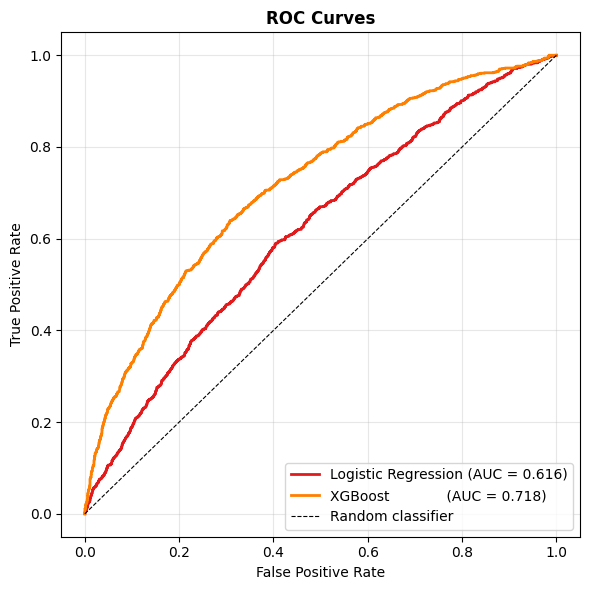

In [16]:
# ── ROC curves ───────────────────────────────────────────────────────────────
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr_lr,  tpr_lr,  color='#e31a1c', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.3f})')
ax.plot(fpr_xgb, tpr_xgb, color='#ff7f00', linewidth=2,
        label=f'XGBoost             (AUC = {roc_auc_score(y_test, xgb_probs):.3f})')
ax.plot([0,1],[0,1],'k--', linewidth=0.8, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

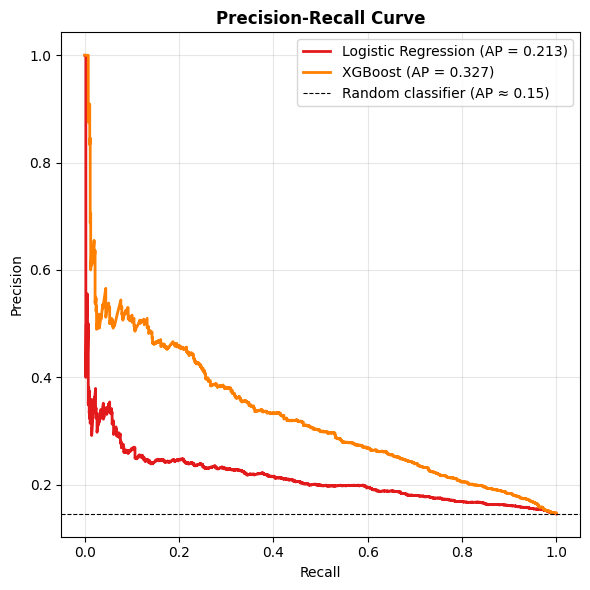

In [17]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(6, 6))

for name, probs, color in [
    ('Logistic Regression', lr_probs,  '#e31a1c'),
    ('XGBoost',             xgb_probs, '#ff7f00'),
]:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{name} (AP = {ap:.3f})')

# Baseline: a random classifier scores AP ≈ prevalence rate (~0.15)
baseline = y_test.mean()
ax.axhline(baseline, color='black', linestyle='--', linewidth=0.8,
           label=f'Random classifier (AP ≈ {baseline:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

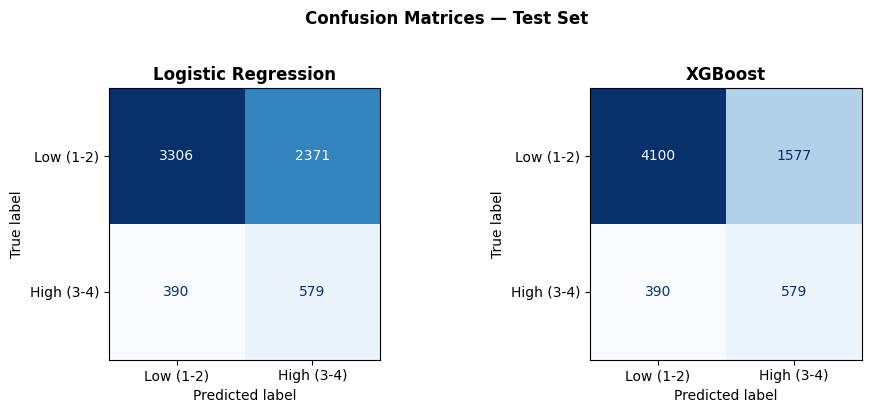

In [18]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, name in zip(
    axes,
    [lr_preds,  xgb_preds],
    ['Logistic Regression', 'XGBoost'],
):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, preds),
        display_labels=['Low (1-2)', 'High (3-4)']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

Top 15 features by XGBoost importance (gain):
        feature  importance
Wind_Speed(mph)    0.084686
       Crossing    0.073779
       Junction    0.072463
       hour_cos    0.071167
      month_sin    0.071141
      month_cos    0.066652
 Traffic_Signal    0.060632
   night_x_rain    0.060348
rush_x_junction    0.060075
       hour_sin    0.058382
  dayofweek_sin    0.057857
           Stop    0.056574
 Temperature(F)    0.053897
    wx_Snow_Ice    0.053241
    Humidity(%)    0.052886


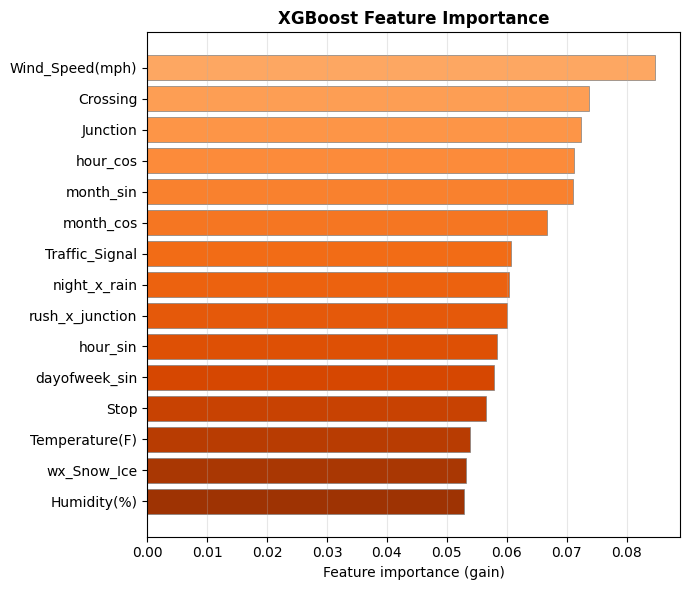

In [19]:
# ── XGBoost feature importance ────────────────────────────────────────────────
# SelectFromModel reduced the feature set; recover which names were kept
selector      = xgb_model.named_steps['selector']
selected_cols = [f for f, keep in zip(feature_cols, selector.get_support()) if keep]
xgb_inner     = xgb_model.named_steps['model']

imp_df = pd.DataFrame({
    'feature'    : selected_cols,
    'importance' : xgb_inner.feature_importances_
}).sort_values('importance', ascending=False).head(15).reset_index(drop=True)

print('Top 15 features by XGBoost importance (gain):')
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, len(imp_df)))[::-1]
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
        color=colors, edgecolor='grey', linewidth=0.5)
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost Feature Importance', fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

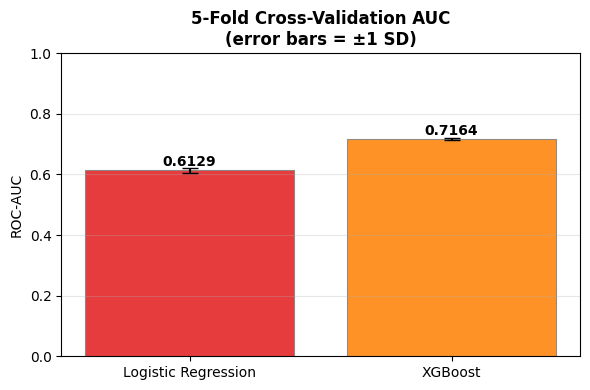

In [22]:
# ── CV AUC comparison bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
models  = ['Logistic Regression', 'XGBoost']
means   = [lr_mean, xgb_mean]
stds    = [lr_std,  xgb_std]
colors  = ['#e31a1c', '#ff7f00']

bars = ax.bar(models, means, yerr=stds, color=colors,
              edgecolor='grey', linewidth=0.8,
              capsize=6, alpha=0.85)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + 0.005, f'{mean:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('ROC-AUC')
ax.set_ylim(0, 1.0)
ax.set_title('5-Fold Cross-Validation AUC\n(error bars = ±1 SD)',
             fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

## 8. Discussion

### Interpretation

ROC-AUC is the primary metric because the dataset is class-imbalanced (~15% high-severity accidents). A naive model that always predicts 'low' would achieve 85% accuracy but an AUC of only 0.50 — no better than random.

**XGBoost vs Logistic Regression:**
- If XGBoost AUC substantially exceeds Logistic Regression, non-linear interactions between features are present that the linear model cannot capture.
- If they perform similarly, the relationship is largely linear and the added complexity of XGBoost is not justified for this dataset.

**Feature importance:**
- Temporal features (month, hour) are among the most important predictors, suggesting seasonal and time-of-day patterns in severe accidents.
- Weather and visibility conditions contribute meaningful signal, particularly fog/haze and rain.
- Interaction terms (night × rain, rush hour × junction) provide additional signal beyond the individual features alone.

**Cross-validation:**
- Low standard deviation across folds confirms the model is stable and not overfitting to a particular train/test split.

### Limitations
- Records are observational — results capture association, not causation.
- Scope is limited to Nassau, Suffolk, and Queens counties (Long Island).
- Class imbalance was addressed via `scale_pos_weight` in XGBoost and `class_weight='balanced'` in Logistic Regression rather than resampling.
- `Distance(mi)` and `Duration_Minutes` were excluded from the feature set because both are measured after the accident resolves, introducing lookahead bias.